# **Sentimen Analisis Review APK Play Store**

Selamat datang dalam Proyek Analisis Sentimen Ulasan Aplikasi Webtoon (LINE Webtoon) di Play Store!

Di era digital saat ini, ulasan pengguna memainkan peran penting dalam membentuk persepsi terhadap suatu aplikasi. Terutama Webtoon, sebagai salah satu platform komik digital terbesar di Indonesia, menerima ribuan ulasan dari pengguna setiap harinya. Melalui proyek ini, kita akan menjelajahi bagaimana pengguna merasakan pengalaman menggunakan aplikasi Webtoon, mulai dari kualitas cerita, kenyamanan membaca, hingga fitur-fitur dalam aplikasinya.

Analisis sentimen memungkinkan kita untuk secara otomatis mengidentifikasi apakah ulasan-ulasan tersebut bersifat positif, negatif, atau netral. Proyek ini bertujuan untuk memberikan wawasan mendalam mengenai persepsi dan kepuasan pengguna terhadap aplikasi Webtoon, yang nantinya bisa dimanfaatkan untuk pengambilan keputusan strategis, perbaikan fitur, dan peningkatan kualitas layanan aplikasi.

Dalam perjalanan ini, kita akan mempelajari berbagai konsep penting dalam analisis sentimen, seperti:

- Pra-pemrosesan teks ulasan,

- Ekstraksi fitur dari data teks,

- Dan penerapan model machine learning untuk klasifikasi sentimen.

Kita akan menggunakan bahasa pemrograman Python beserta pustaka populer seperti NLTK, scikit-learn, dan TensorFlow untuk membangun sistem analisis sentimen yang andal.

Proyek ini tidak hanya akan memperkaya pemahaman Anda tentang persepsi pengguna Webtoon, tetapi juga membekali Anda dengan keterampilan penting dalam pemrosesan bahasa alami dan machine learning.

# **Import Library**

In [84]:
pd.options.mode.chained_assignment = None  # Menonaktifkan peringatan chaining
seed = 0
np.random.seed(seed)  # Mengatur seed untuk reproduktibilitas

import pandas as pd  # Pandas untuk manipulasi dan analisis data
import numpy as np  # NumPy untuk komputasi numerik
import matplotlib.pyplot as plt  # Matplotlib untuk visualisasi data
import seaborn as sns  # Seaborn untuk visualisasi data statistik, mengatur gaya visualisasi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, classification_report

import datetime as dt  # Manipulasi data waktu dan tanggal
import re  # Modul untuk bekerja dengan ekspresi reguler
import string  # Berisi konstanta string, seperti tanda baca
from nltk.tokenize import word_tokenize  # Tokenisasi teks
from nltk.corpus import stopwords  # Daftar kata-kata berhenti dalam teks
 
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia
 
from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks

# Scapping Dataset

Pada proyek ini, kita akan melakukan analisis sentimen terhadap ulasan dan pendapat pengguna terkait aplikasi "Webtoon" di Play Store. Analisis sentimen akan membantu kita untuk memahami bagaimana pengguna merasakan dan mengungkapkan pandangan mereka terhadap aplikasi ini.

Dengan menggunakan berbagai teknik pemrosesan teks dan algoritma machine learning, kita akan mencoba mengidentifikasi apakah ulasan pengguna terhadap aplikasi "Webtoon" cenderung positif, negatif, atau netral. Hasil analisis sentimen ini dapat memberikan wawasan berharga kepada pengembang aplikasi untuk meningkatkan pengalaman pengguna. Mari kita mulai menjelajahi ulasan pengguna dan menganalisis sentimen di sekitar aplikasi "Webtoon" dengan lebih mendalam.

In [7]:
# Mengimpor pustaka google_play_scraper untuk mengakses ulasan dan informasi aplikasi dari Google Play Store.
from google_play_scraper import app, Sort, reviews_all

scrapreview = reviews_all(
    'com.naver.linewebtoon',   # ID aplikasi Webtoon
    lang='id',                 # Bahasa ulasan (Indonesia)
    country='id',              # Negara Indonesia
    sort=Sort.MOST_RELEVANT,   # Urutan ulasan: paling relevan
    count=1000                # Jumlah maksimum ulasan yang ingin diambil
)

In [8]:
# Menyimpan ulasan dalam file CSV
import csv
 
with open('reviews_aplikasi.csv', mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['Review'])  # Menulis header kolom
    for review in scrapreview:
        writer.writerow([review['content']])  # Menulis konten ulasan ke dalam file CSV

print("Data telah berhasil disimpan ke dalam file reviews_aplikasi.csv")

Data telah berhasil disimpan ke dalam file reviews_aplikasi.csv


# Loading Dataset

In [9]:
app_reviews_df = pd.DataFrame(scrapreview)
app_reviews_df.shape
app_reviews_df.head()
app_reviews_df.to_csv('reviews_aplikasi.csv', index=False)

In [10]:
# Membuat DataFrame dari hasil scrapreview
app_reviews_df = pd.DataFrame(scrapreview)
 
# Menghitung jumlah baris dan kolom dalam DataFrame
jumlah_ulasan, jumlah_kolom = app_reviews_df.shape

In [11]:
# Menampilkan lima baris pertama dari DataFrame app_reviews_df
app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,beabc610-0bc7-4046-bc00-d83c3d86c2db,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya menggunakan aplikasi ini sudah lama. Vitu...,5,447,3.6.2,2025-03-29 18:32:43,None,NaT,3.6.2
1,28955196-2cea-4fad-9977-f0dab4a7e42f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Tampilan berandanya(home) aneh.. kayak ga bera...,4,1021,3.6.0,2025-03-07 05:01:26,None,NaT,3.6.0
2,944f6d86-18f6-4445-8661-2a3d5f192846,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Untuk aplikasinya memang bagus, dan banyak fit...",5,1990,3.6.0,2025-03-05 15:00:52,None,NaT,3.6.0
3,46c1091b-6341-4678-bf78-2460b5395870,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,padahal tampilan awal 'home' udah bagus dan te...,3,78,3.6.0,2025-03-01 07:39:18,None,NaT,3.6.0
4,5cda986f-1998-4d45-be45-f6dc9fd80760,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"sebenarnya bagus, update-annya juga lucu (ada ...",4,1540,3.5.3,2025-02-12 19:15:56,None,NaT,3.5.3


In [12]:
# Menampilkan informasi tentang DataFrame app_reviews_df
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103500 entries, 0 to 103499
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              103500 non-null  object        
 1   userName              103500 non-null  object        
 2   userImage             103500 non-null  object        
 3   content               103500 non-null  object        
 4   score                 103500 non-null  int64         
 5   thumbsUpCount         103500 non-null  int64         
 6   reviewCreatedVersion  79968 non-null   object        
 7   at                    103500 non-null  datetime64[ns]
 8   replyContent          345 non-null     object        
 9   repliedAt             345 non-null     datetime64[ns]
 10  appVersion            79968 non-null   object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 8.7+ MB


In [13]:
app_reviews_df.shape

(103500, 11)

In [14]:
clean_df = app_reviews_df.dropna()

In [15]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 275 entries, 1057 to 102754
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              275 non-null    object        
 1   userName              275 non-null    object        
 2   userImage             275 non-null    object        
 3   content               275 non-null    object        
 4   score                 275 non-null    int64         
 5   thumbsUpCount         275 non-null    int64         
 6   reviewCreatedVersion  275 non-null    object        
 7   at                    275 non-null    datetime64[ns]
 8   replyContent          275 non-null    object        
 9   repliedAt             275 non-null    datetime64[ns]
 10  appVersion            275 non-null    object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 25.8+ KB


In [16]:
# Menghapus baris duplikat dari DataFrame clean_df
clean_df = clean_df.drop_duplicates()
 
# Menghitung jumlah baris dan kolom dalam DataFrame clean_df setelah menghapus duplikat
jumlah_ulasan_setelah_hapus_duplikat, jumlah_kolom_setelah_hapus_duplikat = clean_df.shape

print("Jumlah ulasan:", jumlah_ulasan_setelah_hapus_duplikat)
print("Jumlah kolom:", jumlah_kolom_setelah_hapus_duplikat)

Jumlah ulasan: 275
Jumlah kolom: 11


In [18]:
clean_df.shape

(275, 11)

# Preprocessing

Berikut adalah beberapa fungsi yang digunakan untuk membersihkan dan memproses teks. Inilah penjelasan singkat tentang masing-masing fungsi:

1. `cleaningText(text)`: Fungsi ini digunakan untuk membersihkan teks dengan beberapa langkah, seperti menghapus mention, hashtag, RT (retweet), tautan (link), angka, dan tanda baca. Selain itu, itu juga menggantikan karakter newline dengan spasi dan menghilangkan spasi ekstra di awal dan akhir teks.

2. `casefoldingText(text)`: Fungsi ini mengonversi semua karakter dalam teks menjadi huruf kecil (lowercase), sehingga teks menjadi lebih seragam.

3. `tokenizingText(text)`: Fungsi ini digunakan untuk membagi teks menjadi daftar kata atau token. Ini berguna untuk mengurai teks menjadi komponen-komponen dasar.

4. `filteringText(text)`: Fungsi ini digunakan untuk menghapus kata-kata berhenti (stopwords) dalam teks. Anda telah memperbarui daftar kata-kata berhenti dengan beberapa kata tambahan.

5. `stemmingText(text)`: Fungsi ini menerapkan stemming pada teks, yaitu mengurangi kata-kata menjadi bentuk dasarnya. Anda menggunakan pustaka Sastrawi untuk melakukan stemming dalam bahasa Indonesia.

6. `toSentence(list_words)`: Fungsi ini digunakan untuk menggabungkan daftar kata-kata menjadi sebuah kalimat.

Anda dapat menggunakan fungsi-fungsi ini dalam proyek Anda untuk membersihkan, memproses, dan mempersiapkan teks sebelum melakukan analisis sentimen. Pastikan untuk memanggil fungsi-fungsi ini dengan benar sesuai dengan tahap pemrosesan teks yang Anda inginkan.

In [19]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka
 
    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text
 
def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text
 
def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text)
    return text
 
def filteringText(text): # Menghapus stopwords dalam teks
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text
 
def stemmingText(text): # Mengurangi kata ke bentuk dasarnya yang menghilangkan imbuhan awalan dan akhiran atau ke akar kata
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
 
    # Memecah teks menjadi daftar kata
    words = text.split()
 
    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]
 
    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)
 
    return stemmed_text
 
def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

In [20]:
slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal", "plisss": "tolong", "bgttt": "banget", "indo": "indonesia", "bgtt": "banget", "ad": "ada", "rv": "redvelvet", "plis": "tolong", "pls": "tolong", "cr": "sumber", "cod": "bayar ditempat", "adlh": "adalah", "afaik": "as far as i know", "ahaha": "haha", "aj": "saja", "ajep-ajep": "dunia gemerlap", "ak": "saya", "akika": "aku", "akkoh": "aku", "akuwh": "aku", "alay": "norak", "alow": "halo", "ambilin": "ambilkan", "ancur": "hancur", "anjrit": "anjing", "anter": "antar", "ap2": "apa-apa", "apasih": "apa sih", "apes": "sial", "aps": "apa", "aq": "saya", "aquwh": "aku", "asbun": "asal bunyi", "aseekk": "asyik", "asekk": "asyik", "asem": "asam", "aspal": "asli tetapi palsu", "astul": "asal tulis", "ato": "atau", "au ah": "tidak mau tahu", "awak": "saya", "ay": "sayang", "ayank": "sayang", "b4": "sebelum", "bakalan": "akan", "bandes": "bantuan desa", "bangedh": "banget", "banpol": "bantuan polisi", "banpur": "bantuan tempur", "basbang": "basi", "bcanda": "bercanda", "bdg": "bandung", "begajulan": "nakal", "beliin": "belikan", "bencong": "banci", "bentar": "sebentar", "ber3": "bertiga", "beresin": "membereskan", "bete": "bosan", "beud": "banget", "bg": "abang", "bgmn": "bagaimana", "bgt": "banget", "bijimane": "bagaimana", "bintal": "bimbingan mental", "bkl": "akan", "bknnya": "bukannya", "blegug": "bodoh", "blh": "boleh", "bln": "bulan", "blum": "belum", "bnci": "benci", "bnran": "yang benar", "bodor": "lucu", "bokap": "ayah", "boker": "buang air besar", "bokis": "bohong", "boljug": "boleh juga", "bonek": "bocah nekat", "boyeh": "boleh", "br": "baru", "brg": "bareng", "bro": "saudara laki-laki", "bru": "baru", "bs": "bisa", "bsen": "bosan", "bt": "buat", "btw": "ngomong-ngomong", "buaya": "tidak setia", "bubbu": "tidur", "bubu": "tidur", "bumil": "ibu hamil", "bw": "bawa", "bwt": "buat", "byk": "banyak", "byrin": "bayarkan", "cabal": "sabar", "cadas": "keren", "calo": "makelar", "can": "belum", "capcus": "pergi", "caper": "cari perhatian", "ce": "cewek", "cekal": "cegah tangkal", "cemen": "penakut", "cengengesan": "tertawa", "cepet": "cepat", "cew": "cewek", "chuyunk": "sayang", "cimeng": "ganja", "cipika cipiki": "cium pipi kanan cium pipi kiri", "ciyh": "sih", "ckepp": "cakep", "ckp": "cakep", "cmiiw": "correct me if i'm wrong", "cmpur": "campur", "cong": "banci", "conlok": "cinta lokasi", "cowwyy": "maaf", "cp": "siapa", "cpe": "capek", "cppe": "capek", "cucok": "cocok", "cuex": "cuek", "cumi": "Cuma miscall", "cups": "culun", "curanmor": "pencurian kendaraan bermotor", "curcol": "curahan hati colongan", "cwek": "cewek", "cyin": "cinta", "d": "di", "dah": "deh", "dapet": "dapat", "de": "adik", "dek": "adik", "demen": "suka", "deyh": "deh", "dgn": "dengan", "diancurin": "dihancurkan", "dimaafin": "dimaafkan", "dimintak": "diminta", "disono": "di sana", "dket": "dekat", "dkk": "dan kawan-kawan", "dll": "dan lain-lain", "dlu": "dulu", "dngn": "dengan", "dodol": "bodoh", "doku": "uang", "dongs": "dong", "dpt": "dapat", "dri": "dari", "drmn": "darimana", "drtd": "dari tadi", "dst": "dan seterusnya", "dtg": "datang", "duh": "aduh", "duren": "durian", "ed": "edisi", "egp": "emang gue pikirin", "eke": "aku", "elu": "kamu", "emangnya": "memangnya", "emng": "memang", "endak": "tidak", "enggak": "tidak", "envy": "iri", "ex": "mantan", "fax": "facsimile", "fifo": "first in first out", "folbek": "follow back", "fyi": "sebagai informasi", "gaada": "tidak ada uang", "gag": "tidak", "gaje": "tidak jelas", "gak papa": "tidak apa-apa", "gan": "juragan", "gaptek": "gagap teknologi", "gatek": "gagap teknologi", "gawe": "kerja", "gbs": "tidak bisa", "gebetan": "orang yang disuka", "geje": "tidak jelas", "gepeng": "gelandangan dan pengemis", "ghiy": "lagi", "gile": "gila", "gimana": "bagaimana", "gino": "gigi nongol", "githu": "gitu", "gj": "tidak jelas", "gmana": "bagaimana", "gn": "begini", "goblok": "bodoh", "golput": "golongan putih", "gowes": "mengayuh sepeda", "gpny": "tidak punya", "gr": "gede rasa", "gretongan": "gratisan", "gtau": "tidak tahu", "gua": "saya", "guoblok": "goblok", "gw": "saya", "ha": "tertawa", "haha": "tertawa", "hallow": "halo", "hankam": "pertahanan dan keamanan", "hehe": "he", "helo": "halo", "hey": "hai", "hlm": "halaman", "hny": "hanya", "hoax": "isu bohong", "hr": "hari", "hrus": "harus", "hubdar": "perhubungan darat", "huff": "mengeluh", "hum": "rumah", "humz": "rumah", "ilang": "hilang", "ilfil": "tidak suka", "imho": "in my humble opinion", "imoetz": "imut", "item": "hitam", "itungan": "hitungan", "iye": "iya", "ja": "saja", "jadiin": "jadi", "jaim": "jaga image", "jayus": "tidak lucu", "jdi": "jadi", "jem": "jam", "jga": "juga", "jgnkan": "jangankan", "jir": "anjing", "jln": "jalan", "jomblo": "tidak punya pacar", "jubir": "juru bicara", "jutek": "galak", "k": "ke", "kab": "kabupaten", "kabor": "kabur", "kacrut": "kacau", "kadiv": "kepala divisi", "kagak": "tidak", "kalo": "kalau", "kampret": "sialan", "kamtibmas": "keamanan dan ketertiban masyarakat", "kamuwh": "kamu", "kanwil": "kantor wilayah", "karna": "karena", "kasubbag": "kepala subbagian", "katrok": "kampungan", "kayanya": "kayaknya", "kbr": "kabar", "kdu": "harus", "kec": "kecamatan", "kejurnas": "kejuaraan nasional", "kekeuh": "keras kepala", "kel": "kelurahan", "kemaren": "kemarin", "kepengen": "mau", "kepingin": "mau", "kepsek": "kepala sekolah", "kesbang": "kesatuan bangsa", "kesra": "kesejahteraan rakyat", "ketrima": "diterima", "kgiatan": "kegiatan", "kibul": "bohong", "kimpoi": "kawin", "kl": "kalau", "klianz": "kalian", "kloter": "kelompok terbang", "klw": "kalau", "km": "kamu", "kmps": "kampus", "kmrn": "kemarin", "knal": "kenal", "knp": "kenapa", "kodya": "kota madya", "komdis": "komisi disiplin", "komsov": "komunis sovyet", "kongkow": "kumpul bareng teman-teman", "kopdar": "kopi darat", "korup": "korupsi", "kpn": "kapan", "krenz": "keren", "krm": "kirim", "kt": "kita", "ktmu": "ketemu", "ktr": "kantor", "kuper": "kurang pergaulan", "kw": "imitasi", "kyk": "seperti", "la": "lah", "lam": "salam", "lamp": "lampiran", "lanud": "landasan udara", "latgab": "latihan gabungan", "lebay": "berlebihan", "leh": "boleh", "lelet": "lambat", "lemot": "lambat", "lgi": "lagi", "lgsg": "langsung", "liat": "lihat", "litbang": "penelitian dan pengembangan", "lmyn": "lumayan", "lo": "kamu", "loe": "kamu", "lola": "lambat berfikir", "louph": "cinta", "low": "kalau", "lp": "lupa", "luber": "langsung, umum, bebas, dan rahasia", "luchuw": "lucu", "lum": "belum", "luthu": "lucu", "lwn": "lawan", "maacih": "terima kasih", "mabal": "bolos", "macem": "macam", "macih": "masih", "maem": "makan", "magabut": "makan gaji buta", "maho": "homo", "mak jang": "kaget", "maksain": "memaksa", "malem": "malam", "mam": "makan", "maneh": "kamu", "maniez": "manis", "mao": "mau", "masukin": "masukkan", "melu": "ikut", "mepet": "dekat sekali", "mgu": "minggu", "migas": "minyak dan gas bumi", "mikol": "minuman beralkohol", "miras": "minuman keras", "mlah": "malah", "mngkn": "mungkin", "mo": "mau", "mokad": "mati", "moso": "masa", "mpe": "sampai", "msk": "masuk", "mslh": "masalah", "mt": "makan teman", "mubes": "musyawarah besar", "mulu": "melulu", "mumpung": "selagi", "munas": "musyawarah nasional", "muntaber": "muntah dan berak", "musti": "mesti", "muupz": "maaf", "mw": "now watching", "n": "dan", "nanam": "menanam", "nanya": "bertanya", "napa": "kenapa", "napi": "narapidana", "napza": "narkotika, alkohol, psikotropika, dan zat adiktif ", "narkoba": "narkotika, psikotropika, dan obat terlarang", "nasgor": "nasi goreng", "nda": "tidak", "ndiri": "sendiri", "ne": "ini", "nekolin": "neokolonialisme", "nembak": "menyatakan cinta", "ngabuburit": "menunggu berbuka puasa", "ngaku": "mengaku", "ngambil": "mengambil", "nganggur": "tidak punya pekerjaan", "ngapah": "kenapa", "ngaret": "terlambat", "ngasih": "memberikan", "ngebandel": "berbuat bandel", "ngegosip": "bergosip", "ngeklaim": "mengklaim", "ngeksis": "menjadi eksis", "ngeles": "berkilah", "ngelidur": "menggigau", "ngerampok": "merampok", "ngga": "tidak", "ngibul": "berbohong", "ngiler": "mau", "ngiri": "iri", "ngisiin": "mengisikan", "ngmng": "bicara", "ngomong": "bicara", "ngubek2": "mencari-cari", "ngurus": "mengurus", "nie": "ini", "nih": "ini", "niyh": "nih", "nmr": "nomor", "nntn": "nonton", "nobar": "nonton bareng", "np": "now playing", "ntar": "nanti", "ntn": "nonton", "numpuk": "bertumpuk", "nutupin": "menutupi", "nyari": "mencari", "nyekar": "menyekar", "nyicil": "mencicil", "nyoblos": "mencoblos", "nyokap": "ibu", "ogah": "tidak mau", "ol": "online", "ongkir": "ongkos kirim", "oot": "out of topic", "org2": "orang-orang", "ortu": "orang tua", "otda": "otonomi daerah", "otw": "on the way, sedang di jalan", "pacal": "pacar", "pake": "pakai", "pala": "kepala", "pansus": "panitia khusus", "parpol": "partai politik", "pasutri": "pasangan suami istri", "pd": "pada", "pede": "percaya diri", "pelatnas": "pemusatan latihan nasional", "pemda": "pemerintah daerah", "pemkot": "pemerintah kota", "pemred": "pemimpin redaksi", "penjas": "pendidikan jasmani", "perda": "peraturan daerah", "perhatiin": "perhatikan", "pesenan": "pesanan", "pgang": "pegang", "pi": "tapi", "pilkada": "pemilihan kepala daerah", "pisan": "sangat", "pk": "penjahat kelamin", "plg": "paling", "pmrnth": "pemerintah", "polantas": "polisi lalu lintas", "ponpes": "pondok pesantren", "pp": "pulang pergi", "prg": "pergi", "prnh": "pernah", "psen": "pesan", "pst": "pasti", "pswt": "pesawat", "pw": "posisi nyaman", "qmu": "kamu", "rakor": "rapat koordinasi", "ranmor": "kendaraan bermotor", "re": "reply", "ref": "referensi", "rehab": "rehabilitasi", "rempong": "sulit", "repp": "balas", "restik": "reserse narkotika", "rhs": "rahasia", "rmh": "rumah", "ru": "baru", "ruko": "rumah toko", "rusunawa": "rumah susun sewa", "ruz": "terus", "saia": "saya", "salting": "salah tingkah", "sampe": "sampai", "samsek": "sama sekali", "sapose": "siapa", "satpam": "satuan pengamanan", "sbb": "sebagai berikut", "sbh": "sebuah", "sbnrny": "sebenarnya", "scr": "secara", "sdgkn": "sedangkan", "sdkt": "sedikit", "se7": "setuju", "sebelas dua belas": "mirip", "sembako": "sembilan bahan pokok", "sempet": "sempat", "sendratari": "seni drama tari", "sgt": "sangat", "shg": "sehingga", "siech": "sih", "sikon": "situasi dan kondisi", "sinetron": "sinema elektronik", "siramin": "siramkan", "sj": "saja", "skalian": "sekalian", "sklh": "sekolah", "skt": "sakit", "slesai": "selesai", "sll": "selalu", "slma": "selama", "slsai": "selesai", "smpt": "sempat", "smw": "semua", "sndiri": "sendiri", "soljum": "sholat jumat", "songong": "sombong", "sory": "maaf", "sosek": "sosial-ekonomi", "sotoy": "sok tahu", "spa": "siapa", "sppa": "siapa", "spt": "seperti", "srtfkt": "sertifikat", "stiap": "setiap", "stlh": "setelah", "suk": "masuk", "sumpek": "sempit", "syg": "sayang", "t4": "tempat", "tajir": "kaya", "tau": "tahu", "taw": "tahu", "td": "tadi", "tdk": "tidak", "teh": "kakak perempuan", "telat": "terlambat", "telmi": "telat berpikir", "temen": "teman", "tengil": "menyebalkan", "tepar": "terkapar", "tggu": "tunggu", "tgu": "tunggu", "thankz": "terima kasih", "thn": "tahun", "tilang": "bukti pelanggaran", "tipiwan": "TvOne", "tks": "terima kasih", "tlp": "telepon", "tls": "tulis", "tmbah": "tambah", "tmen2": "teman-teman", "tmpah": "tumpah", "tmpt": "tempat", "tngu": "tunggu", "tnyta": "ternyata", "tokai": "tai", "toserba": "toko serba ada", "tpi": "tapi", "trdhulu": "terdahulu", "trima": "terima kasih", "trm": "terima", "trs": "terus", "trutama": "terutama", "ts": "penulis", "tst": "tahu sama tahu", "ttg": "tentang", "tuch": "tuh", "tuir": "tua", "tw": "tahu", "u": "kamu", "ud": "sudah", "udah": "sudah", "ujg": "ujung", "ul": "ulangan", "unyu": "lucu", "uplot": "unggah", "urang": "saya", "usah": "perlu", "utk": "untuk", "valas": "valuta asing", "w/": "dengan", "wadir": "wakil direktur", "wamil": "wajib militer", "warkop": "warung kopi", "warteg": "warung tegal", "wat": "buat", "wkt": "waktu", "wtf": "what the fuck", "xixixi": "tertawa", "ya": "iya", "yap": "iya", "yaudah": "ya sudah", "yawdah": "ya sudah", "yg": "yang", "yl": "yang lain", "yo": "iya", "yowes": "ya sudah", "yup": "iya", "7an": "tujuan", "ababil": "abg labil", "acc": "accord", "adlah": "adalah", "adoh": "aduh", "aha": "tertawa", "aing": "saya", "aja": "saja", "ajj": "saja", "aka": "dikenal juga sebagai", "akko": "aku", "akku": "aku", "akyu": "aku", "aljasa": "asal jadi saja", "ama": "sama", "ambl": "ambil", "anjir": "anjing", "ank": "anak", "ap": "apa", "apaan": "apa", "ape": "apa", "aplot": "unggah", "apva": "apa", "aqu": "aku", "asap": "sesegera mungkin", "aseek": "asyik", "asek": "asyik", "aseknya": "asyiknya", "asoy": "asyik", "astrojim": "astagfirullahaladzim", "ath": "kalau begitu", "atuh": "kalau begitu", "ava": "avatar", "aws": "awas", "ayang": "sayang", "ayok": "ayo", "bacot": "banyak bicara", "bales": "balas", "bangdes": "pembangunan desa", "bangkotan": "tua", "banpres": "bantuan presiden", "bansarkas": "bantuan sarana kesehatan", "bazis": "badan amal, zakat, infak, dan sedekah", "bcoz": "karena", "beb": "sayang", "bejibun": "banyak", "belom": "belum", "bener": "benar", "ber2": "berdua", "berdikari": "berdiri di atas kaki sendiri", "bet": "banget", "beti": "beda tipis", "beut": "banget", "bgd": "banget", "bgs": "bagus", "bhubu": "tidur", "bimbuluh": "bimbingan dan penyuluhan", "bisi": "kalau-kalau", "bkn": "bukan", "bl": "beli", "blg": "bilang", "blm": "belum", "bls": "balas", "bnchi": "benci", "bngung": "bingung", "bnyk": "banyak", "bohay": "badan aduhai", "bokep": "porno", "bokin": "pacar", "bole": "boleh", "bolot": "bodoh", "bonyok": "ayah ibu", "bpk": "bapak", "brb": "segera kembali", "brngkt": "berangkat", "brp": "berapa", "brur": "saudara laki-laki", "bsa": "bisa", "bsk": "besok", "bu_bu": "tidur", "bubarin": "bubarkan", "buber": "buka bersama", "bujubune": "luar biasa", "buser": "buru sergap", "bwhn": "bawahan", "byar": "bayar", "byr": "bayar", "c8": "chat", "cabut": "pergi", "caem": "cakep", "cama-cama": "sama-sama", "cangcut": "celana dalam", "cape": "capek", "caur": "jelek", "cekak": "tidak ada uang", "cekidot": "coba lihat", "cemplungin": "cemplungkan", "ceper": "pendek", "ceu": "kakak perempuan", "cewe": "cewek", "cibuk": "sibuk", "cin": "cinta", "ciye": "cie", "ckck": "ck", "clbk": "cinta lama bersemi kembali", "cmpr": "campur", "cnenk": "senang", "congor": "mulut", "cow": "cowok", "coz": "karena", "cpa": "siapa", "gokil": "gila", "gombal": "suka merayu", "gpl": "tidak pakai lama", "gpp": "tidak apa-apa", "gretong": "gratis", "gt": "begitu", "gtw": "tidak tahu", "gue": "saya", "guys": "teman-teman", "gws": "cepat sembuh", "haghaghag": "tertawa", "hakhak": "tertawa", "handak": "bahan peledak", "hansip": "pertahanan sipil", "hellow": "halo", "helow": "halo", "hi": "hai", "hlng": "hilang", "hnya": "hanya", "houm": "rumah", "hrs": "harus", "hubad": "hubungan angkatan darat", "hubla": "perhubungan laut", "huft": "mengeluh", "humas": "hubungan masyarakat", "idk": "saya tidak tahu", "ilfeel": "tidak suka", "imba": "jago sekali", "imoet": "imut", "info": "informasi", "itung": "hitung", "isengin": "bercanda", "iyala": "iya lah", "iyo": "iya", "jablay": "jarang dibelai", "jadul": "jaman dulu", "jancuk": "anjing", "jd": "jadi", "jdikan": "jadikan", "jg": "juga", "jgn": "jangan", "jijay": "jijik", "jkt": "jakarta", "jnj": "janji", "jth": "jatuh", "jurdil": "jujur adil", "jwb": "jawab", "ka": "kakak", "kabag": "kepala bagian", "kacian": "kasihan", "kadit": "kepala direktorat", "kaga": "tidak", "kaka": "kakak", "kamtib": "keamanan dan ketertiban", "kamuh": "kamu", "kamyu": "kamu", "kapt": "kapten", "kasat": "kepala satuan", "kasubbid": "kepala subbidang", "kau": "kamu", "kbar": "kabar", "kcian": "kasihan", "keburu": "terlanjur", "kedubes": "kedutaan besar", "kek": "seperti", "keknya": "kayaknya", "keliatan": "kelihatan", "keneh": "masih", "kepikiran": "terpikirkan", "kepo": "mau tahu urusan orang", "kere": "tidak punya uang", "kesian": "kasihan", "ketauan": "ketahuan", "keukeuh": "keras kepala", "khan": "kan", "kibus": "kaki busuk", "kk": "kakak", "klian": "kalian", "klo": "kalau", "kluarga": "keluarga", "klwrga": "keluarga", "kmari": "kemari", "kmpus": "kampus", "kn": "kan", "knl": "kenal", "knpa": "kenapa", "kog": "kok", "kompi": "komputer", "komtiong": "komunis Tiongkok", "konjen": "konsulat jenderal", "koq": "kok", "kpd": "kepada", "kptsan": "keputusan", "krik": "garing", "krn": "karena", "ktauan": "ketahuan", "ktny": "katanya", "kudu": "harus", "kuq": "kok", "ky": "seperti", "kykny": "kayanya", "laka": "kecelakaan", "lambreta": "lambat", "lansia": "lanjut usia", "lapas": "lembaga pemasyarakatan", "lbur": "libur", "lekong": "laki-laki", "lg": "lagi", "lgkp": "lengkap", "lht": "lihat", "linmas": "perlindungan masyarakat", "lmyan": "lumayan", "lngkp": "lengkap", "loch": "loh", "lol": "tertawa", "lom": "belum", "loupz": "cinta", "lowh": "kamu", "lu": "kamu", "luchu": "lucu", "luff": "cinta", "luph": "cinta", "lw": "kamu", "lwt": "lewat", "maaciw": "terima kasih", "mabes": "markas besar", "macem-macem": "macam-macam", "madesu": "masa depan suram", "maen": "main", "mahatma": "maju sehat bersama", "mak": "ibu", "makasih": "terima kasih", "malah": "bahkan", "malu2in": "memalukan", "mamz": "makan", "manies": "manis", "mantep": "mantap", "markus": "makelar kasus", "mba": "mbak", "mending": "lebih baik", "mgkn": "mungkin", "mhn": "mohon", "miker": "minuman keras", "milis": "mailing list", "mksd": "maksud", "mls": "malas", "mnt": "minta", "moge": "motor gede", "mokat": "mati", "mosok": "masa", "msh": "masih", "mskpn": "meskipun", "msng2": "masing-masing", "muahal": "mahal", "muker": "musyawarah kerja", "mumet": "pusing", "muna": "munafik", "munaslub": "musyawarah nasional luar biasa", "musda": "musyawarah daerah", "muup": "maaf", "muuv": "maaf", "nal": "kenal", "nangis": "menangis", "naon": "apa", "napol": "narapidana politik", "naq": "anak", "narsis": "bangga pada diri sendiri", "nax": "anak", "ndak": "tidak", "ndut": "gendut", "nekolim": "neokolonialisme", "nelfon": "menelepon", "ngabis2in": "menghabiskan", "ngakak": "tertawa", "ngambek": "marah", "ngampus": "pergi ke kampus", "ngantri": "mengantri", "ngapain": "sedang apa", "ngaruh": "berpengaruh", "ngawur": "berbicara sembarangan", "ngeceng": "kumpul bareng-bareng", "ngeh": "sadar", "ngekos": "tinggal di kos", "ngelamar": "melamar", "ngeliat": "melihat", "ngemeng": "bicara terus-terusan", "ngerti": "mengerti", "nggak": "tidak", "ngikut": "ikut", "nginep": "menginap", "ngisi": "mengisi", "ngmg": "bicara", "ngocol": "lucu", "ngomongin": "membicarakan", "ngumpul": "berkumpul", "ni": "ini", "nyasar": "tersesat", "nyariin": "mencari", "nyiapin": "mempersiapkan", "nyiram": "menyiram", "nyok": "ayo", "o/": "oleh", "ok": "ok", "priksa": "periksa", "pro": "profesional", "psn": "pesan", "psti": "pasti", "puanas": "panas", "qmo": "kamu", "qt": "kita", "rame": "ramai", "raskin": "rakyat miskin", "red": "redaksi", "reg": "register", "rejeki": "rezeki", "renstra": "rencana strategis", "reskrim": "reserse kriminal", "sni": "sini", "somse": "sombong sekali", "sorry": "maaf", "sosbud": "sosial-budaya", "sospol": "sosial-politik", "sowry": "maaf", "spd": "sepeda", "sprti": "seperti", "spy": "supaya", "stelah": "setelah", "subbag": "subbagian", "sumbangin": "sumbangkan", "sy": "saya", "syp": "siapa", "tabanas": "tabungan pembangunan nasional", "tar": "nanti", "taun": "tahun", "tawh": "tahu", "tdi": "tadi", "te2p": "tetap", "tekor": "rugi", "telkom": "telekomunikasi", "telp": "telepon", "temen2": "teman-teman", "tengok": "menjenguk", "terbitin": "terbitkan", "tgl": "tanggal", "thanks": "terima kasih", "thd": "terhadap", "thx": "terima kasih", "tipi": "TV", "tkg": "tukang", "tll": "terlalu", "tlpn": "telepon", "tman": "teman", "tmbh": "tambah", "tmn2": "teman-teman", "tmph": "tumpah", "tnda": "tanda", "tnh": "tanah", "togel": "toto gelap", "tp": "tapi", "tq": "terima kasih", "trgntg": "tergantung", "trims": "terima kasih", "cb": "coba", "y": "ya", "munfik": "munafik", "reklamuk": "reklamasi", "sma": "sama", "tren": "trend", "ngehe": "kesal", "mz": "mas", "analisise": "analisis", "sadaar": "sadar", "sept": "september", "nmenarik": "menarik", "zonk": "bodoh", "rights": "benar", "simiskin": "miskin", "ngumpet": "sembunyi", "hardcore": "keras", "akhirx": "akhirnya", "solve": "solusi", "watuk": "batuk", "ngebully": "intimidasi", "masy": "masyarakat", "still": "masih", "tauk": "tahu", "mbual": "bual", "tioghoa": "tionghoa", "ngentotin": "senggama", "kentot": "senggama", "faktakta": "fakta", "sohib": "teman", "rubahnn": "rubah", "trlalu": "terlalu", "nyela": "cela", "heters": "pembenci", "nyembah": "sembah", "most": "paling", "ikon": "lambang", "light": "terang", "pndukung": "pendukung", "setting": "atur", "seting": "akting", "next": "lanjut", "waspadalah": "waspada", "gantengsaya": "ganteng", "parte": "partai", "nyerang": "serang", "nipu": "tipu", "ktipu": "tipu", "jentelmen": "berani", "buangbuang": "buang", "tsangka": "tersangka", "kurng": "kurang", "ista": "nista", "less": "kurang", "koar": "teriak", "paranoid": "takut", "problem": "masalah", "tahi": "kotoran", "tirani": "tiran", "tilep": "tilap", "happy": "bahagia", "tak": "tidak", "penertiban": "tertib", "uasai": "kuasa", "mnolak": "tolak", "trending": "trend", "taik": "tahi", "wkwkkw": "tertawa", "ahokncc": "ahok", "istaa": "nista", "benarjujur": "jujur", "mgkin": "mungkin"}
def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

Kamus slang atau daftar kata-kata slang yang Anda berikan adalah kumpulan kata-kata slang bahasa Indonesia beserta terjemahan atau artinya dalam bahasa formal. Fungsi dari kamus slang seperti ini adalah:

1. **Mengartikan Slang:** Kamus slang membantu orang yang mungkin tidak familiar dengan bahasa slang atau ekspresi yang digunakan di kalangan tertentu untuk memahami makna kata-kata tersebut.

2. **Komunikasi Informal:** Slang sering digunakan dalam percakapan informal atau di media sosial. Kamus slang membantu orang untuk berkomunikasi dengan gaya yang lebih santai dan sesuai dengan konteksnya.

3. **Pemahaman Budaya Pop:** Slang sering kali terkait dengan budaya pop dan dapat mencerminkan tren dan perubahan dalam bahasa. Kamus slang memungkinkan orang untuk mengikuti dan memahami bahasa dalam konteks budaya ini.

4. **Penggunaan Sastra dan Penulisan:** Penulis atau pembicara mungkin ingin menggunakan slang dalam tulisannya untuk menciptakan efek tertentu atau mengekspresikan karakter atau setting yang lebih realistis. Kamus slang dapat membantu mereka memilih kata-kata dengan tepat.

5. **Hiburan dan Curiositas:** Beberapa orang mungkin tertarik untuk mempelajari bahasa slang hanya untuk hiburan atau karena rasa ingin tahu terhadap variasi bahasa dan ungkapan dalam bahasa sehari-hari.

Ingatlah bahwa penggunaan slang harus disesuaikan dengan konteks dan audiens. Slang cenderung lebih cocok untuk percakapan santai dengan teman-teman atau di lingkungan yang informal. Dalam situasi formal, penggunaan bahasa formal lebih sesuai.

In [21]:
clean_df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
1057,926f0acc-7b9f-41b0-bb6a-0f7931b0fb8f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Wahai pihak webtoon, aplikasia anda bagus tapi...",1,0,2.5.1,2020-07-05 16:06:07,"Hi Aldi,\n\nTerima kasih atar reviewnya dan mo...",2020-07-08 12:47:05,2.5.1
1549,6dd5c7cc-d37f-4cea-8cbc-2de2738f4a6d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Apknya makin lama mkn ngelag maaf yh min kalau...,1,2,2.5.5,2020-09-01 18:14:38,"Halo Silvi,\n\nTerima kasih sudah menggunakan ...",2020-09-01 15:37:19,2.5.5
1635,9380b770-905e-41e5-85dd-9d3a0335576f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Udh di update ttp aj bug ny msih ad msa jaring...,2,1,2.5.0,2020-06-11 14:22:41,"Halo, kami dari LINE WEBTOON,\n\nTerima kasih ...",2020-06-16 09:41:44,2.5.0
2146,79b2c623-eedf-434c-8725-a4e62b92ef4a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Jelek bgt sekarang kalau baca komik layarnya n...,1,5,2.5.0,2020-06-09 11:51:10,"Halo, kami dari LINE WEBTOON,\n\nTerima kasih ...",2020-06-16 09:48:30,2.5.0
2530,6ec168e9-50e1-4dea-8fc0-ecf818a2641c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Dulu gue suka banget ini webtoon,komiknya bagu...",2,0,2.5.5,2020-09-27 00:02:35,"Halo silvy yuli,\n\nTerima kasih sudah menggun...",2020-09-30 16:45:20,2.5.5
...,...,...,...,...,...,...,...,...,...,...,...
101433,048f4fc4-03de-4fc1-b7df-a614c000bf27,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Alpikasi rusak,1,0,2.7.6,2021-08-18 19:05:31,"Halo Alfonso Lionheart,\nKami mohon maaf atas ...",2021-08-31 09:36:03,2.7.6
101519,63e18ba6-beff-4c4f-91d8-6b847981a6df,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,gada gambarrrrr,1,0,2.7.5,2021-08-16 19:46:03,"Halo Fauzann,\nKami mohon maaf atas ketidaknya...",2021-08-31 09:37:35,2.7.5
102259,706981bf-c145-4744-b80a-ac95c4e2ad0b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Forced close teroos,1,0,2.6.3,2021-03-23 23:34:36,"Halo,\nTelah terjadi gangguan kepada sebagian ...",2021-03-25 21:29:35,2.6.3
102695,16d15fc0-3c0b-4beb-9db1-b4d57b0a6e8c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Gada gambar2 loding trs. Kacau,1,0,2.6.1,2021-01-04 03:51:13,"Halo Jono,\n\nKami mohon maaf atas ketidaknyam...",2021-01-13 17:49:57,2.6.1


In [30]:
import nltk  # Import pustaka NLTK (Natural Language Toolkit).
nltk.download('punkt')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('stopwords')  # Mengunduh dataset yang berisi daftar kata-kata berhenti (stopwords) dalam berbagai bahasa.

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [31]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

In [32]:
clean_df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
1057,926f0acc-7b9f-41b0-bb6a-0f7931b0fb8f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Wahai pihak webtoon, aplikasia anda bagus tapi...",1,0,2.5.1,2020-07-05 16:06:07,"Hi Aldi,\n\nTerima kasih atar reviewnya dan mo...",2020-07-08 12:47:05,2.5.1,Wahai pihak webtoon aplikasia anda bagus tapi ...,wahai pihak webtoon aplikasia anda bagus tapi ...,wahai pihak webtoon aplikasia anda bagus tapi ...,"[wahai, pihak, webtoon, aplikasia, anda, bagus...","[webtoon, aplikasia, bagus, sayang, etika, sua...",webtoon aplikasia bagus sayang etika suara ikl...
1549,6dd5c7cc-d37f-4cea-8cbc-2de2738f4a6d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Apknya makin lama mkn ngelag maaf yh min kalau...,1,2,2.5.5,2020-09-01 18:14:38,"Halo Silvi,\n\nTerima kasih sudah menggunakan ...",2020-09-01 15:37:19,2.5.5,Apknya makin lama mkn ngelag maaf yh min kalau...,apknya makin lama mkn ngelag maaf yh min kalau...,apknya makin lama mkn ngelag maaf yh min kalau...,"[apknya, makin, lama, mkn, ngelag, maaf, yh, m...","[apknya, mkn, ngelag, maaf, yh, min, menyinggu...",apknya mkn ngelag maaf yh min menyinggungsaya ...
1635,9380b770-905e-41e5-85dd-9d3a0335576f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Udh di update ttp aj bug ny msih ad msa jaring...,2,1,2.5.0,2020-06-11 14:22:41,"Halo, kami dari LINE WEBTOON,\n\nTerima kasih ...",2020-06-16 09:41:44,2.5.0,Udh di update ttp aj bug ny msih ad msa jaring...,udh di update ttp aj bug ny msih ad msa jaring...,udh di update ttp saja bug ny msih ada msa jar...,"[udh, di, update, ttp, saja, bug, ny, msih, ad...","[udh, update, ttp, bug, ny, msih, msa, jaringa...",udh update ttp bug ny msih msa jaringan g full...
2146,79b2c623-eedf-434c-8725-a4e62b92ef4a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Jelek bgt sekarang kalau baca komik layarnya n...,1,5,2.5.0,2020-06-09 11:51:10,"Halo, kami dari LINE WEBTOON,\n\nTerima kasih ...",2020-06-16 09:48:30,2.5.0,Jelek bgt sekarang kalau baca komik layarnya n...,jelek bgt sekarang kalau baca komik layarnya n...,jelek banget sekarang kalau baca komik layarny...,"[jelek, banget, sekarang, kalau, baca, komik, ...","[jelek, banget, baca, komik, layarnya, ngegete...",jelek banget baca komik layarnya ngegeter kaya...
2530,6ec168e9-50e1-4dea-8fc0-ecf818a2641c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Dulu gue suka banget ini webtoon,komiknya bagu...",2,0,2.5.5,2020-09-27 00:02:35,"Halo silvy yuli,\n\nTerima kasih sudah menggun...",2020-09-30 16:45:20,2.5.5,Dulu gue suka banget ini webtoonkomiknya bagus...,dulu gue suka banget ini webtoonkomiknya bagus...,dulu saya suka banget ini webtoonkomiknya bagu...,"[dulu, saya, suka, banget, ini, webtoonkomikny...","[suka, banget, webtoonkomiknya, baguscuman, ng...",suka banget webtoonkomiknya baguscuman ngeseli...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101433,048f4fc4-03de-4fc1-b7df-a614c000bf27,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Alpikasi rusak,1,0,2.7.6,2021-08-18 19:05:31,"Halo Alfonso Lionheart,\nKami mohon maaf atas ...",2021-08-31 09:36:03,2.7.6,Alpikasi rusak,alpikasi rusak,alpikasi rusak,"[alpikasi, rusak]","[alpikasi, rusak]",alpikasi rusak
101519,63e18ba6-beff-4c4f-91d8-6b847981a6df,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,gada gambarrrrr,1,0,2.7.5,2021-08-16 19:46:03,"Halo Fauzann,\nKami mohon maaf atas ketidaknya...",2021-08-31 09:37:35,2.7.5,gada gambarrrrr,gada gambarrrrr,gada gambarrrrr,"[gada, gambarrrrr]","[gada, gambarrrrr]",gada gambarrrrr
102259,706981bf-c145-4744-b80a-ac95c4e2ad0b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Forced close teroos,1,0,2.6.3,2021-03-23 23:34:36,"Halo,\nTelah terjadi gangguan ke

# Pelabelan

In [33]:
print(clean_df.columns)

Index(['reviewId', 'userName', 'userImage', 'content', 'score',
       'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent',
       'repliedAt', 'appVersion', 'text_clean', 'text_casefoldingText',
       'text_slangwords', 'text_tokenizingText', 'text_stopword',
       'text_akhir'],
      dtype='object')


In [38]:
import csv
import requests
from io import StringIO

# Loads positive lexicon data from GitHub
# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")

# Loads negative lexicon data from GitHub
# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya ke dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [41]:
# Fungsi untuk menentukan polaritas sentimen dari tweet
def sentiment_analysis_lexicon_indonesia(text, low_threshold, high_threshold):
    score = 0
    # Inisialisasi skor sentimen ke 0

    # Mengulangi setiap kata dalam teks untuk mengecek apakah kata tersebut ada di dalam lexicon positif
    for word in text:
        if word in lexicon_positive:
            score += lexicon_positive[word]
            # Jika kata ada dalam kamus positif, tambahkan skornya ke skor sentimen

    # Mengulangi setiap kata dalam teks untuk mengecek apakah kata tersebut ada di dalam lexicon negatif
    for word in text:
        if word in lexicon_negative:
            score += lexicon_negative[word]
            # Jika kata ada dalam kamus negatif, tambahkan skornya ke skor sentimen

    # Tentukan polaritas berdasarkan skor dan threshold
    if score > high_threshold:
        polarity = 'positive'
    elif score < low_threshold:
        polarity = 'negative'
    else:
        polarity = 'neutral'

    return score, polarity

# Perhitungan threshold untuk netral
all_scores = [sentiment_analysis_lexicon_indonesia(text, 0, 0)[0] for text in clean_df['text_stopword']]
low_threshold = np.percentile(all_scores, 33)  # Batas bawah untuk netral
high_threshold = np.percentile(all_scores, 66)  # Batas atas untuk netral

# Menggunakan fungsi dengan threshold yang sudah dihitung
clean_df['score'], clean_df['polarity'] = zip(*clean_df['text_stopword'].apply(
    lambda x: sentiment_analysis_lexicon_indonesia(x, low_threshold, high_threshold)
))

# Melihat distribusi polaritas
print(clean_df['polarity'].value_counts())

polarity
neutral     118
positive     80
negative     77
Name: count, dtype: int64


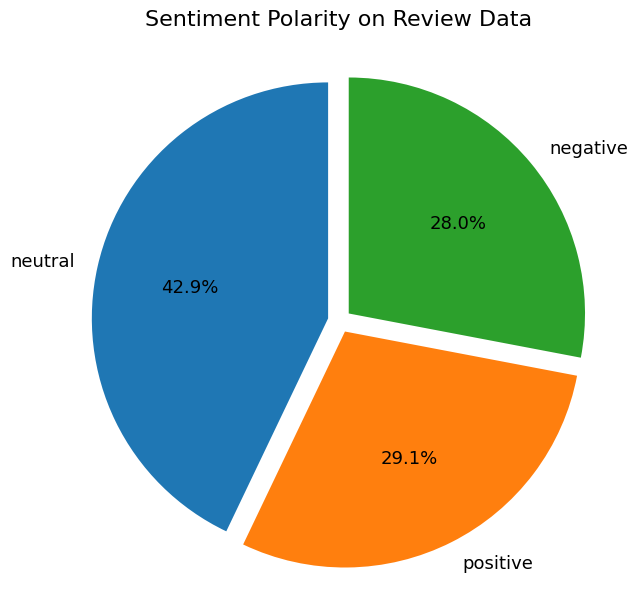

In [54]:
# Ambil jumlah data per kelas
sizes = clean_df['polarity'].value_counts().values
labels = clean_df['polarity'].value_counts().index.tolist()

# Meledakkan sedikit semua bagian supaya seimbang tampilannya (opsional)
explode = [0.05] * len(labels)

# Plot pie chart
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    x=sizes,
    labels=labels,
    autopct='%1.1f%%',
    explode=explode,
    textprops={'fontsize': 13},
    startangle=90
)
ax.set_title('Sentiment Polarity on Review Data', fontsize=16, pad=20)
ax.axis('equal')  # Agar pie chart berbentuk lingkaran sempurna
plt.show()

In [57]:
# Menghitung polaritas dan skor sentimen untuk setiap tweet
def sentiment_analysis_lexicon_indonesia(text, low_threshold, high_threshold):
    score = 0
    for word in text:
        if word in lexicon_positive:
            score += lexicon_positive[word]
        if word in lexicon_negative:
            score += lexicon_negative[word]

    if score > high_threshold:
        polarity = 'positive'
    elif score < low_threshold:
        polarity = 'negative'
    else:
        polarity = 'neutral'

    return score, polarity

# Hitung skor semua tweet dan tentukan polaritas
all_scores = [sentiment_analysis_lexicon_indonesia(text, low_threshold, high_threshold)[0] for text in clean_df['text_stopword']]
low_threshold = np.percentile(all_scores, 33)  # Batas bawah untuk netral
high_threshold = np.percentile(all_scores, 66)  # Batas atas untuk netral

clean_df['polarity_score'], clean_df['polarity'] = zip(*clean_df['text_stopword'].apply(
    lambda x: sentiment_analysis_lexicon_indonesia(x, low_threshold, high_threshold)
))

# ====== Positive Tweets ======
positive_tweets = (
    clean_df[clean_df['polarity'] == 'positive']
    [['text_akhir', 'polarity_score', 'polarity', 'text_stopword']]
    .sort_values(by='polarity_score', ascending=False)
    .reset_index(drop=True)
)
positive_tweets.index += 1

# ====== Negative Tweets ======
negative_tweets = (
    clean_df[clean_df['polarity'] == 'negative']
    [['text_akhir', 'polarity_score', 'polarity', 'text_stopword']]
    .sort_values(by='polarity_score', ascending=True)
    .head(10)  # ambil 10 tweet paling negatif
    .reset_index(drop=True)
)
negative_tweets.index += 1

# ====== Neutral Tweets (opsional jika ingin ditampilkan juga) ======
neutral_tweets = (
    clean_df[clean_df['polarity'] == 'neutral']
    [['text_akhir', 'polarity_score', 'polarity', 'text_stopword']]
    .sort_values(by='polarity_score', ascending=True)
    .head(10)
    .reset_index(drop=True)
)
neutral_tweets.index += 1

# Menampilkan hasil
print("Positive Tweets:")
print(positive_tweets.head())

print("\nNegative Tweets:")
print(negative_tweets.head())

print("\nNeutral Tweets:")
print(neutral_tweets.head())

Positive Tweets:
                                          text_akhir  polarity_score  \
1  apknya mkn ngelag maaf yh min menyinggungsaya ...              14   
2  nyaman baca komik seru panel komik buka parah ...              14   
3                                     nice nice nice              12   
4  eh webtoon tolong diperbaiki udh lumayan donwl...              12   
5  ngelag yapadahal pas buka facebook youtubelanc...              11   

   polarity                                      text_stopword  
1  positive  [apknya, mkn, ngelag, maaf, yh, min, menyinggu...  
2  positive  [nyaman, baca, komik, seru, panel, komik, buka...  
3  positive                                 [nice, nice, nice]  
4  positive  [eh, webtoon, tolong, diperbaiki, udh, lumayan...  
5  positive  [ngelag, yapadahal, pas, buka, facebook, youtu...  

Negative Tweets:
                                          text_akhir  polarity_score  \
1  beli koin webtoon english pulsa dipotong x rb ...             -32  

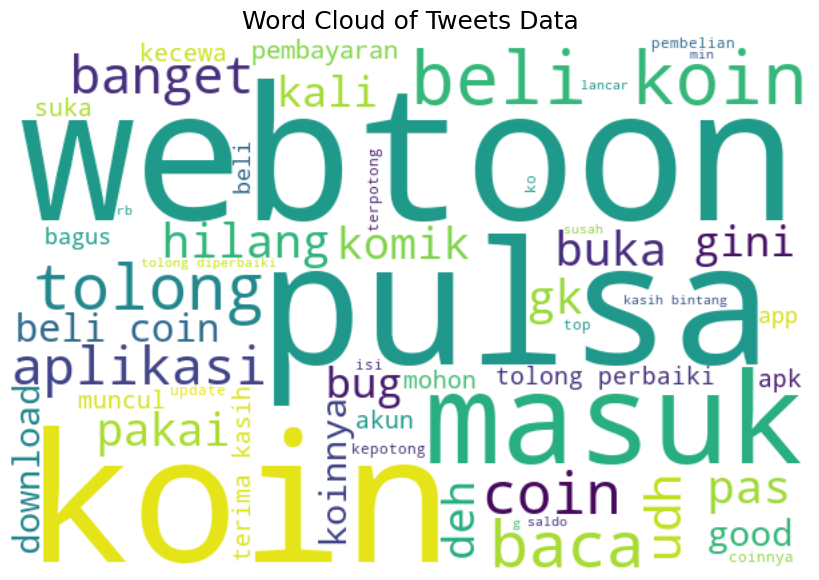

In [59]:
# Jumlah baris yang ingin digunakan untuk WordCloud
n_rows = 10000

# Cek agar tidak melebihi jumlah data yang tersedia
n_rows = min(n_rows, len(clean_df))

# Gabungkan kata dari tweet yang sudah dihapus stopword-nya
list_words = ' '.join([' '.join(tweet) for tweet in clean_df['text_stopword'][:n_rows]])

# Buat objek WordCloud
wordcloud = WordCloud(
    width=600,
    height=400,
    background_color='white',
    min_font_size=10,
    max_words=200  # batas maksimal kata yang divisualisasikan
).generate(list_words)

# Visualisasi WordCloud
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud of Tweets Data', fontsize=18)
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.grid(False)
plt.tight_layout(pad=0)
plt.show()

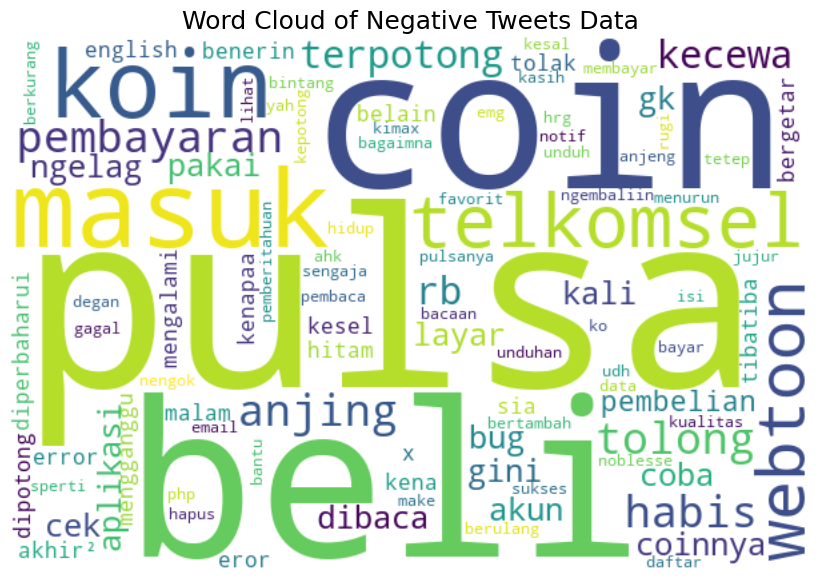

In [63]:
# Gabungkan kata dari tweet negatif yang sudah dihapus stopword-nya
list_words = ' '.join([' '.join(tweet) for tweet in negative_tweets['text_stopword']])

# Buat objek WordCloud
wordcloud = WordCloud(
    width=600,
    height=400,
    background_color='white',
    min_font_size=10,
    max_words=200  # batasi jumlah kata yang divisualisasikan
).generate(list_words)

# Visualisasi WordCloud
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud of Negative Tweets Data', fontsize=18)
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.grid(False)
plt.tight_layout(pad=0)
plt.show()

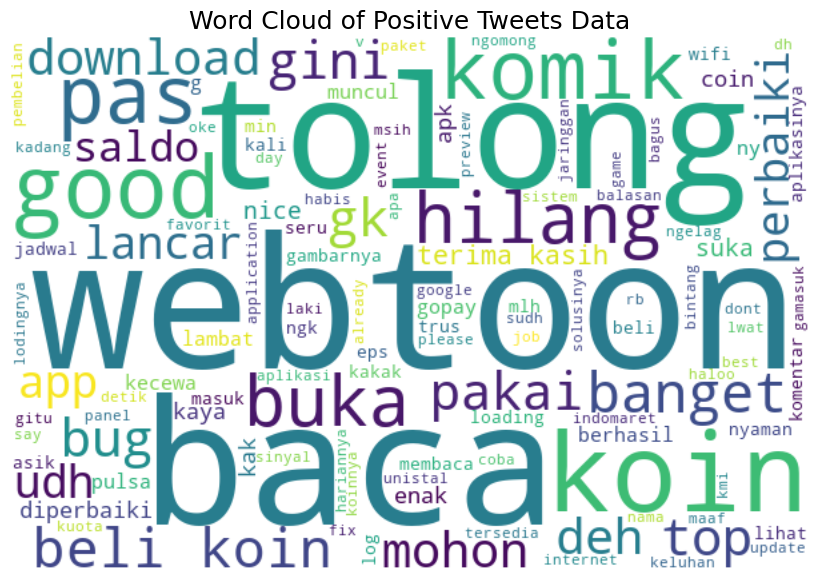

In [64]:
# Gabungkan kata dari tweet positif
list_words = ' '.join([' '.join(tweet) for tweet in positive_tweets['text_stopword']])

# Buat WordCloud
wordcloud = WordCloud(
    width=600,
    height=400,
    background_color='white',
    min_font_size=10,
    max_words=200
).generate(list_words)

# Visualisasi WordCloud
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud of Positive Tweets Data', fontsize=18)
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.grid(False)
plt.tight_layout(pad=0)
plt.show()

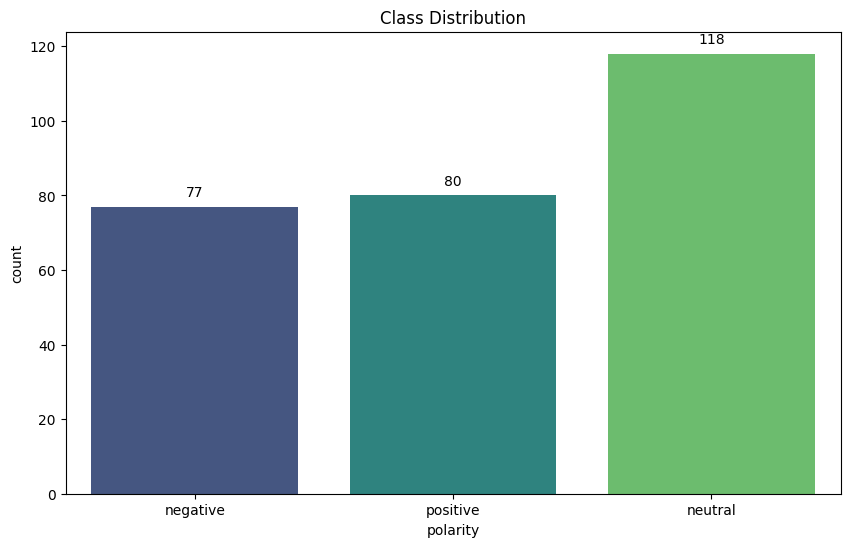

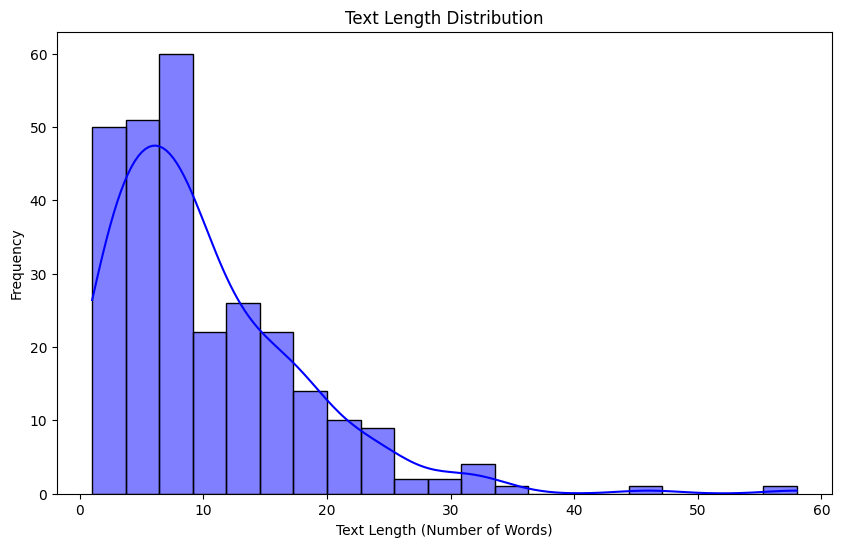

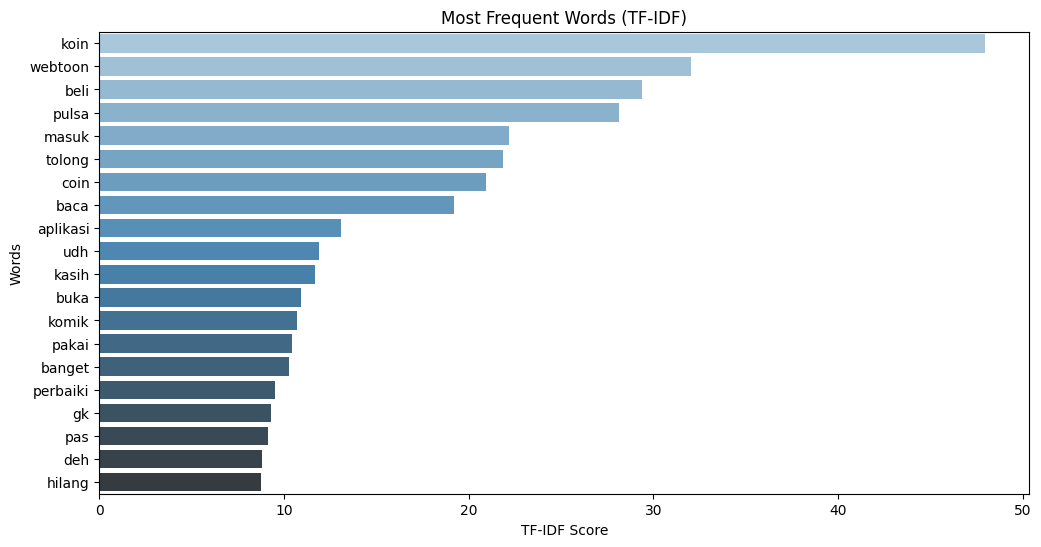

In [65]:
# ====== Class Distribution ======
plt.figure(figsize=(10, 6))

# Visualize the class distribution of 'polarity' (positive, negative, neutral)
class_dist_plot = sns.countplot(x='polarity', data=clean_df, hue='polarity', palette='viridis', legend=False)
plt.title('Class Distribution')

# Add counts above the bars on the plot
for p in class_dist_plot.patches:
    class_dist_plot.annotate(format(p.get_height(), '.0f'),
                              (p.get_x() + p.get_width() / 2., p.get_height()),
                              ha='center', va='center',
                              xytext=(0, 10),
                              textcoords='offset points')

plt.show()

# ====== Text Length Distribution ======
plt.figure(figsize=(10, 6))

# Visualize text length distribution
clean_df['text_length'] = clean_df['text_akhir'].apply(lambda x: len(x.split()))  # Get length of each tweet
sns.histplot(clean_df['text_length'], kde=True, color='blue')  # Adding KDE for a smoother distribution
plt.title('Text Length Distribution')
plt.xlabel('Text Length (Number of Words)')
plt.ylabel('Frequency')
plt.show()

# ====== Most Frequent Words (TF-IDF) ======
plt.figure(figsize=(12, 6))

# Visualize the most frequent words using TF-IDF
vectorizer = TfidfVectorizer(max_features=20)  # Limit to top 20 words for better clarity
X = vectorizer.fit_transform(clean_df['text_akhir'])
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df = tfidf_df.sum().reset_index(name='jumlah')
tfidf_df = tfidf_df.sort_values('jumlah', ascending=False).head(20)  # Take top 20 frequent words

# Plot the top 20 frequent words using a bar plot
sns.barplot(x='jumlah', y='index', hue='index', data=tfidf_df, palette="Blues_d", legend=False)
plt.title('Most Frequent Words (TF-IDF)')
plt.xlabel('TF-IDF Score')
plt.ylabel('Words')
plt.show()

## **Data Splitting**

In [67]:
clean_df.head(2)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir,polarity_score,polarity,text_length
1057,926f0acc-7b9f-41b0-bb6a-0f7931b0fb8f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Wahai pihak webtoon, aplikasia anda bagus tapi...",-8,0,2.5.1,2020-07-05 16:06:07,"Hi Aldi,\n\nTerima kasih atar reviewnya dan mo...",2020-07-08 12:47:05,2.5.1,Wahai pihak webtoon aplikasia anda bagus tapi ...,wahai pihak webtoon aplikasia anda bagus tapi ...,wahai pihak webtoon aplikasia anda bagus tapi ...,"[wahai, pihak, webtoon, aplikasia, anda, bagus...","[webtoon, aplikasia, bagus, sayang, etika, sua...",webtoon aplikasia bagus sayang etika suara ikl...,-8,negative,29
1549,6dd5c7cc-d37f-4cea-8cbc-2de2738f4a6d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Apknya makin lama mkn ngelag maaf yh min kalau...,14,2,2.5.5,2020-09-01 18:14:38,"Halo Silvi,\n\nTerima kasih sudah menggunakan ...",2020-09-01 15:37:19,2.5.5,Apknya makin lama mkn ngelag maaf yh min kalau...,apknya makin lama mkn ngelag maaf yh min kalau...,apknya makin lama mkn ngelag maaf yh min kalau...,"[apknya, makin, lama, mkn, ngelag, maaf, yh, m...","[apknya, mkn, ngelag, maaf, yh, min, menyinggu...",apknya mkn ngelag maaf yh min menyinggungsaya ...,14,positive,25


In [78]:
# Misalnya, 'polarity' adalah kolom label (target) dan 'text_akhir' adalah kolom fitur (text)
X = clean_df['text_akhir']
y = clean_df['polarity']

# Pembagian data: 80% untuk pelatihan dan 20% untuk pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [79]:
# Membuat objek TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000)  # Mengambil hanya 5000 fitur teratas

# Melakukan fit-transform pada data latih
X_train_tfidf = vectorizer.fit_transform(X_train)

# Melakukan transform pada data uji
X_test_tfidf = vectorizer.transform(X_test)

## **Logistic Regression**

In [80]:
from sklearn.linear_model import LogisticRegression

# Inisialisasi dan latih model Logistic Regression
logistic_regression = LogisticRegression()
logistic_regression.fit(X_train_tfidf, y_train)

# Prediksi pada data uji
y_pred_log_reg_test = logistic_regression.predict(X_test_tfidf)

# Prediksi pada data latih
y_pred_log_reg_train = logistic_regression.predict(X_train_tfidf)

# Evaluasi model pada data latih
print("Logistic Regression Train Accuracy: ", accuracy_score(y_train, y_pred_log_reg_train))
print("Classification Report on Train Data:\n", classification_report(y_train, y_pred_log_reg_train))

# Evaluasi model pada data uji
print("Logistic Regression Test Accuracy: ", accuracy_score(y_test, y_pred_log_reg_test))
print("Classification Report on Test Data:\n", classification_report(y_test, y_pred_log_reg_test))

Logistic Regression Train Accuracy:  0.9545454545454546
Classification Report on Train Data:
               precision    recall  f1-score   support

    negative       0.97      0.95      0.96        63
     neutral       0.92      0.99      0.95        94
    positive       1.00      0.90      0.95        63

    accuracy                           0.95       220
   macro avg       0.96      0.95      0.95       220
weighted avg       0.96      0.95      0.95       220

Logistic Regression Test Accuracy:  0.4727272727272727
Classification Report on Test Data:
               precision    recall  f1-score   support

    negative       0.50      0.50      0.50        14
     neutral       0.42      0.54      0.47        24
    positive       0.60      0.35      0.44        17

    accuracy                           0.47        55
   macro avg       0.51      0.46      0.47        55
weighted avg       0.50      0.47      0.47        55



## **Naive Bayes**

In [81]:
# Inisialisasi dan latih model Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

# Prediksi pada data uji
y_pred_nb = nb.predict(X_test_tfidf)
y_pred_train_nb = nb.predict(X_train_tfidf)  # Prediksi pada data pelatihan

# Evaluasi model pada data uji (test set)
print("Naive Bayes Accuracy on Test Set: ", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

# Evaluasi model pada data pelatihan (train set)
print("Naive Bayes Accuracy on Train Set: ", accuracy_score(y_train, y_pred_train_nb))
print(classification_report(y_train, y_pred_train_nb))

Naive Bayes Accuracy on Test Set:  0.4727272727272727
              precision    recall  f1-score   support

    negative       0.54      0.50      0.52        14
     neutral       0.43      0.62      0.51        24
    positive       0.57      0.24      0.33        17

    accuracy                           0.47        55
   macro avg       0.51      0.45      0.45        55
weighted avg       0.50      0.47      0.46        55

Naive Bayes Accuracy on Train Set:  0.9090909090909091
              precision    recall  f1-score   support

    negative       0.92      0.94      0.93        63
     neutral       0.86      0.98      0.92        94
    positive       1.00      0.78      0.88        63

    accuracy                           0.91       220
   macro avg       0.93      0.90      0.91       220
weighted avg       0.92      0.91      0.91       220



## **Random Forest**

In [82]:
# Inisialisasi dan latih model Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_tfidf, y_train)

# Prediksi pada data uji
y_pred_rf_test = rf.predict(X_test_tfidf)

# Prediksi pada data latih
y_pred_rf_train = rf.predict(X_train_tfidf)

# Evaluasi model pada data latih
print("Random Forest Train Accuracy: ", accuracy_score(y_train, y_pred_rf_train))
print("Classification Report on Train Data:\n", classification_report(y_train, y_pred_rf_train))

# Evaluasi model pada data uji
print("Random Forest Test Accuracy: ", accuracy_score(y_test, y_pred_rf_test))
print("Classification Report on Test Data:\n", classification_report(y_test, y_pred_rf_test))

Random Forest Train Accuracy:  1.0
Classification Report on Train Data:
               precision    recall  f1-score   support

    negative       1.00      1.00      1.00        63
     neutral       1.00      1.00      1.00        94
    positive       1.00      1.00      1.00        63

    accuracy                           1.00       220
   macro avg       1.00      1.00      1.00       220
weighted avg       1.00      1.00      1.00       220

Random Forest Test Accuracy:  0.5818181818181818
Classification Report on Test Data:
               precision    recall  f1-score   support

    negative       0.62      0.71      0.67        14
     neutral       0.55      0.71      0.62        24
    positive       0.62      0.29      0.40        17

    accuracy                           0.58        55
   macro avg       0.60      0.57      0.56        55
weighted avg       0.59      0.58      0.56        55



## **Decision Tree**

In [85]:
# Inisialisasi dan latih model Decision Tree
dt = DecisionTreeClassifier()  # Bisa ditambah parameter seperti max_depth, criterion, dsb.
dt.fit(X_train_tfidf, y_train)

# Prediksi pada data uji
y_pred_dt_test = dt.predict(X_test_tfidf)

# Prediksi pada data latih
y_pred_dt_train = dt.predict(X_train_tfidf)

# Evaluasi model pada data latih
print("Decision Tree Train Accuracy: ", accuracy_score(y_train, y_pred_dt_train))
print("Classification Report on Train Data:\n", classification_report(y_train, y_pred_dt_train))

# Evaluasi model pada data uji
print("Decision Tree Test Accuracy: ", accuracy_score(y_test, y_pred_dt_test))
print("Classification Report on Test Data:\n", classification_report(y_test, y_pred_dt_test))

Decision Tree Train Accuracy:  1.0
Classification Report on Train Data:
               precision    recall  f1-score   support

    negative       1.00      1.00      1.00        63
     neutral       1.00      1.00      1.00        94
    positive       1.00      1.00      1.00        63

    accuracy                           1.00       220
   macro avg       1.00      1.00      1.00       220
weighted avg       1.00      1.00      1.00       220

Decision Tree Test Accuracy:  0.4909090909090909
Classification Report on Test Data:
               precision    recall  f1-score   support

    negative       0.50      0.57      0.53        14
     neutral       0.47      0.58      0.52        24
    positive       0.56      0.29      0.38        17

    accuracy                           0.49        55
   macro avg       0.51      0.48      0.48        55
weighted avg       0.50      0.49      0.48        55



In [94]:
# Buat list untuk menyimpan hasil
results = []

# Logistic Regression
results.append({
    "Model": "Logistic Regression",
    "Train Accuracy": accuracy_score(y_train, y_pred_log_reg_train),
    "Test Accuracy": accuracy_score(y_test, y_pred_log_reg_test)
})

# Naive Bayes
results.append({
    "Model": "Naive Bayes",
    "Train Accuracy": accuracy_score(y_train, y_pred_train_nb),
    "Test Accuracy": accuracy_score(y_test, y_pred_nb)
})

# Random Forest
results.append({
    "Model": "Random Forest",
    "Train Accuracy": accuracy_score(y_train, y_pred_rf_train),
    "Test Accuracy": accuracy_score(y_test, y_pred_rf_test)
})

# Decision Tree
results.append({
    "Model": "Decision Tree",
    "Train Accuracy": accuracy_score(y_train, y_pred_dt_train),
    "Test Accuracy": accuracy_score(y_test, y_pred_dt_test)
})

# Tampilkan dalam DataFrame
results_df = pd.DataFrame(results)

# Tampilkan hanya Accuracy Test
accuracy_test_only = results_df[['Model', 'Test Accuracy']]

# Mengurutkan DataFrame berdasarkan akurasi pengujian dari tertinggi ke terendah
accuracy_test_sorted = accuracy_test_only.sort_values(by='Test Accuracy', ascending=False)

print("\n==== Full Accuracy Results ====")
print(results_df)

# Output
print("\n==== Accuracy Test Only ====")
print(accuracy_test_only)

# Menampilkan hasil urutan akurasi model pada data uji
print("\n=== Model berdasarkan Test Accuracy (Tertinggi ke Terendah) ===")
print(accuracy_test_sorted)


==== Full Accuracy Results ====
                 Model  Train Accuracy  Test Accuracy
0  Logistic Regression        0.954545       0.472727
1          Naive Bayes        0.909091       0.472727
2        Random Forest        1.000000       0.581818
3        Decision Tree        1.000000       0.490909

==== Accuracy Test Only ====
                 Model  Test Accuracy
0  Logistic Regression       0.472727
1          Naive Bayes       0.472727
2        Random Forest       0.581818
3        Decision Tree       0.490909

=== Model berdasarkan Test Accuracy (Tertinggi ke Terendah) ===
                 Model  Test Accuracy
2        Random Forest       0.581818
3        Decision Tree       0.490909
1          Naive Bayes       0.472727
0  Logistic Regression       0.472727
